In [ ]:
# install everything we need
!pip install -q transformers torch scikit-learn pandas numpy matplotlib seaborn openpyxl sentencepiece protobuf

In [1]:
# upload the dataset file
from google.colab import files
import shutil

uploaded = files.upload()


Saving student_assignment_10_cases.xlsx to student_assignment_10_cases.xlsx


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from IPython.display import display
from transformers import pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, cohen_kappa_score,
    classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
XLSX   = 'student_assignment_10_cases.xlsx'

# risk levels ordered from most severe to least
LABELS   = ['attempt', 'behavior', 'ideation', 'indicator', 'safe']
LABEL2ID = {l: i for i, l in enumerate(LABELS)}

print('device :', DEVICE)
print('labels :', LABELS)

device : cuda
labels : ['attempt', 'behavior', 'ideation', 'indicator', 'safe']


In [3]:
# load and preview the dataset
df = pd.read_excel(XLSX, sheet_name='Assignment_Cases')
df.columns = ['case_id', 'dialogue', 'risk_level']
df['risk_level'] = df['risk_level'].str.strip().str.lower()
df['label_id']   = df['risk_level'].map(LABEL2ID)
df['word_count'] = df['dialogue'].apply(lambda x: len(x.split()))

print('total cases  :', len(df))
print('unique labels:', df['risk_level'].nunique())
print('avg words    :', round(df['word_count'].mean()))
print()
print('class breakdown:')
print(df['risk_level'].value_counts().reindex(LABELS))
print()
display(df[['case_id', 'risk_level', 'word_count']])

total cases  : 10
unique labels: 5
avg words    : 315

class breakdown:
risk_level
attempt      2
behavior     2
ideation     2
indicator    2
safe         2
Name: count, dtype: int64



,case_id,risk_level,word_count
0,1,attempt,353
1,2,attempt,386
2,3,behavior,396
3,4,behavior,362
4,5,ideation,375
5,6,ideation,268
6,7,indicator,335
7,8,indicator,289
8,9,safe,184
9,10,safe,203


In [4]:
# method A — BART large zero-shot classifier
# this is a large general-purpose NLI model trained on MNLI


hypotheses_a = {
    'attempt'  : 'This person is expressing suicidal intent or has a plan to end their life.',
    'behavior' : 'This person is showing sustained risk behaviours like social withdrawal or stating a timeline to die.',
    'ideation' : 'This person is experiencing passive suicidal thoughts or a wish to die without a specific plan.',
    'indicator': 'This person is showing early warning signs such as hopelessness or isolation but no suicidal language.',
    'safe'     : 'This person shows no signs of distress and the conversation is completely normal and positive.'
}

candidates_a   = list(hypotheses_a.values())
hyp_to_label_a = {v: k for k, v in hypotheses_a.items()}

print('loading BART-large-MNLI...')
clf_a = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=0 if DEVICE == 'cuda' else -1
)
print('done')

loading BART-large-MNLI...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/515 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

done


In [5]:
# run method A inference on all 10 cases

def truncate(text, max_words=400):
    words = text.split()
    if len(words) > max_words:
        return ' '.join(words[:200] + words[-200:])
    return text

results_a = []
print('running method A (BART)...')
print()

for _, row in df.iterrows():
    out  = clf_a(truncate(row['dialogue']), candidate_labels=candidates_a, multi_label=False)
    pred = hyp_to_label_a[out['labels'][0]]
    conf = out['scores'][0]
    ok   = pred == row['risk_level']
    results_a.append({
        'case_id'    : row['case_id'],
        'true_label' : row['risk_level'],
        'pred_a'     : pred,
        'conf_a'     : round(conf, 3),
        'correct_a'  : ok
    })
    print(f"  case {int(row['case_id']):2d}  true={row['risk_level']:10s}  pred={pred:10s}  {'correct' if ok else 'wrong'}")

df_a = pd.DataFrame(results_a)
acc_a = df_a['correct_a'].mean()
print()
print(f'method A accuracy: {acc_a:.1%}  ({int(acc_a*10)}/10)')

running method A (BART)...

  case  1  true=attempt     pred=ideation    wrong
  case  2  true=attempt     pred=indicator   wrong
  case  3  true=behavior    pred=ideation    wrong
  case  4  true=behavior    pred=ideation    wrong
  case  5  true=ideation    pred=ideation    correct
  case  6  true=ideation    pred=ideation    correct
  case  7  true=indicator   pred=ideation    wrong
  case  8  true=indicator   pred=ideation    wrong
  case  9  true=safe        pred=ideation    wrong
  case 10  true=safe        pred=behavior    wrong

method A accuracy: 20.0%  (2/10)


In [6]:
# method B — DeBERTa-v3 NLI (smaller, faster, domain-adjacent)
# cross-encoder/nli-deberta-v3-small is fine-tuned on NLI tasks
# used here to represent a more compact, deployable model architecture

hypotheses_b = {
    'attempt'  : 'The speaker has expressed a clear intention or plan to attempt suicide.',
    'behavior' : 'The speaker is displaying ongoing risk behaviours consistent with suicidal crisis.',
    'ideation' : 'The speaker has expressed thoughts about death or dying without a clear plan.',
    'indicator': 'The speaker is showing psychological warning signs that may indicate elevated suicide risk.',
    'safe'     : 'The speaker is not at risk and the conversation does not contain any distress signals.'
}

candidates_b   = list(hypotheses_b.values())
hyp_to_label_b = {v: k for k, v in hypotheses_b.items()}

print('loading DeBERTa-v3-small NLI...')
clf_b = pipeline(
    'zero-shot-classification',
    model='cross-encoder/nli-deberta-v3-small',
    device=0 if DEVICE == 'cuda' else -1
)
print('done')

loading DeBERTa-v3-small NLI...


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/568M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/106 [00:00<?, ?it/s]

DebertaV2ForSequenceClassification LOAD REPORT from: cross-encoder/nli-deberta-v3-small
Key                             | Status     |  | 
--------------------------------+------------+--+-
deberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

done


In [7]:
# run method B inference on all 10 cases

results_b = []
print('running method B (DeBERTa)...')
print()

for _, row in df.iterrows():
    out  = clf_b(truncate(row['dialogue']), candidate_labels=candidates_b, multi_label=False)
    pred = hyp_to_label_b[out['labels'][0]]
    conf = out['scores'][0]
    ok   = pred == row['risk_level']
    results_b.append({
        'case_id'    : row['case_id'],
        'true_label' : row['risk_level'],
        'pred_b'     : pred,
        'conf_b'     : round(conf, 3),
        'correct_b'  : ok
    })
    print(f"  case {int(row['case_id']):2d}  true={row['risk_level']:10s}  pred={pred:10s}  {'correct' if ok else 'wrong'}")

df_b = pd.DataFrame(results_b)
acc_b = df_b['correct_b'].mean()
print()
print(f'method B accuracy: {acc_b:.1%}  ({int(acc_b*10)}/10)')

running method B (DeBERTa)...

  case  1  true=attempt     pred=behavior    wrong
  case  2  true=attempt     pred=ideation    wrong
  case  3  true=behavior    pred=ideation    wrong
  case  4  true=behavior    pred=ideation    wrong
  case  5  true=ideation    pred=behavior    wrong
  case  6  true=ideation    pred=ideation    correct
  case  7  true=indicator   pred=attempt     wrong
  case  8  true=indicator   pred=ideation    wrong
  case  9  true=safe        pred=ideation    wrong
  case 10  true=safe        pred=ideation    wrong

method B accuracy: 10.0%  (1/10)


In [8]:
# merge results and compute all evaluation metrics

combined = df_a.merge(df_b[['case_id', 'pred_b', 'conf_b', 'correct_b']], on='case_id')

true   = combined['true_label'].tolist()
pred_a = combined['pred_a'].tolist()
pred_b = combined['pred_b'].tolist()

def ordinal_mae(true_labels, pred_labels):
    return np.mean([abs(LABEL2ID[t] - LABEL2ID[p]) for t, p in zip(true_labels, pred_labels)])

def get_metrics(true_labels, pred_labels, name):
    acc   = accuracy_score(true_labels, pred_labels)
    f1_m  = f1_score(true_labels, pred_labels, labels=LABELS, average='macro',    zero_division=0)
    f1_w  = f1_score(true_labels, pred_labels, labels=LABELS, average='weighted', zero_division=0)
    prec  = precision_score(true_labels, pred_labels, labels=LABELS, average='macro', zero_division=0)
    rec   = recall_score(true_labels, pred_labels, labels=LABELS, average='macro',    zero_division=0)
    kappa = cohen_kappa_score(true_labels, pred_labels, labels=LABELS, weights='quadratic')
    mae   = ordinal_mae(true_labels, pred_labels)
    print(f'\n{name}')
    print(f'  accuracy          {acc:.3f}')
    print(f'  macro f1          {f1_m:.3f}')
    print(f'  weighted f1       {f1_w:.3f}')
    print(f'  macro precision   {prec:.3f}')
    print(f'  macro recall      {rec:.3f}')
    print(f'  cohen kappa       {kappa:.3f}')
    print(f'  mean ordinal err  {mae:.3f}')
    print()
    print(classification_report(true_labels, pred_labels, labels=LABELS, zero_division=0))
    return {'model': name, 'accuracy': acc, 'macro_f1': f1_m,
            'weighted_f1': f1_w, 'precision': prec, 'recall': rec,
            'cohen_kappa': kappa, 'ordinal_mae': mae}

m_a = get_metrics(true, pred_a, 'method A  —  BART large zero-shot')
m_b = get_metrics(true, pred_b, 'method B  —  DeBERTa NLI zero-shot')

summary = pd.DataFrame([m_a, m_b]).set_index('model')
print('summary table')
display(summary.round(3))


method A  —  BART large zero-shot
  accuracy          0.200
  macro f1          0.080
  weighted f1       0.080
  macro precision   0.050
  macro recall      0.200
  cohen kappa       -0.364
  mean ordinal err  1.400

              precision    recall  f1-score   support

     attempt       0.00      0.00      0.00         2
    behavior       0.00      0.00      0.00         2
    ideation       0.25      1.00      0.40         2
   indicator       0.00      0.00      0.00         2
        safe       0.00      0.00      0.00         2

    accuracy                           0.20        10
   macro avg       0.05      0.20      0.08        10
weighted avg       0.05      0.20      0.08        10


method B  —  DeBERTa NLI zero-shot
  accuracy          0.100
  macro f1          0.044
  weighted f1       0.044
  macro precision   0.029
  macro recall      0.100
  cohen kappa       0.000
  mean ordinal err  1.400

              precision    recall  f1-score   support

     attempt      

,accuracy,macro_f1,weighted_f1,precision,recall,cohen_kappa,ordinal_mae
model,,,,,,,
method A — BART large zero-shot,0.2,0.080,0.080,0.050,0.2,-0.364,1.4
method B — DeBERTa NLI zero-shot,0.1,0.044,0.044,0.029,0.1,0.000,1.4


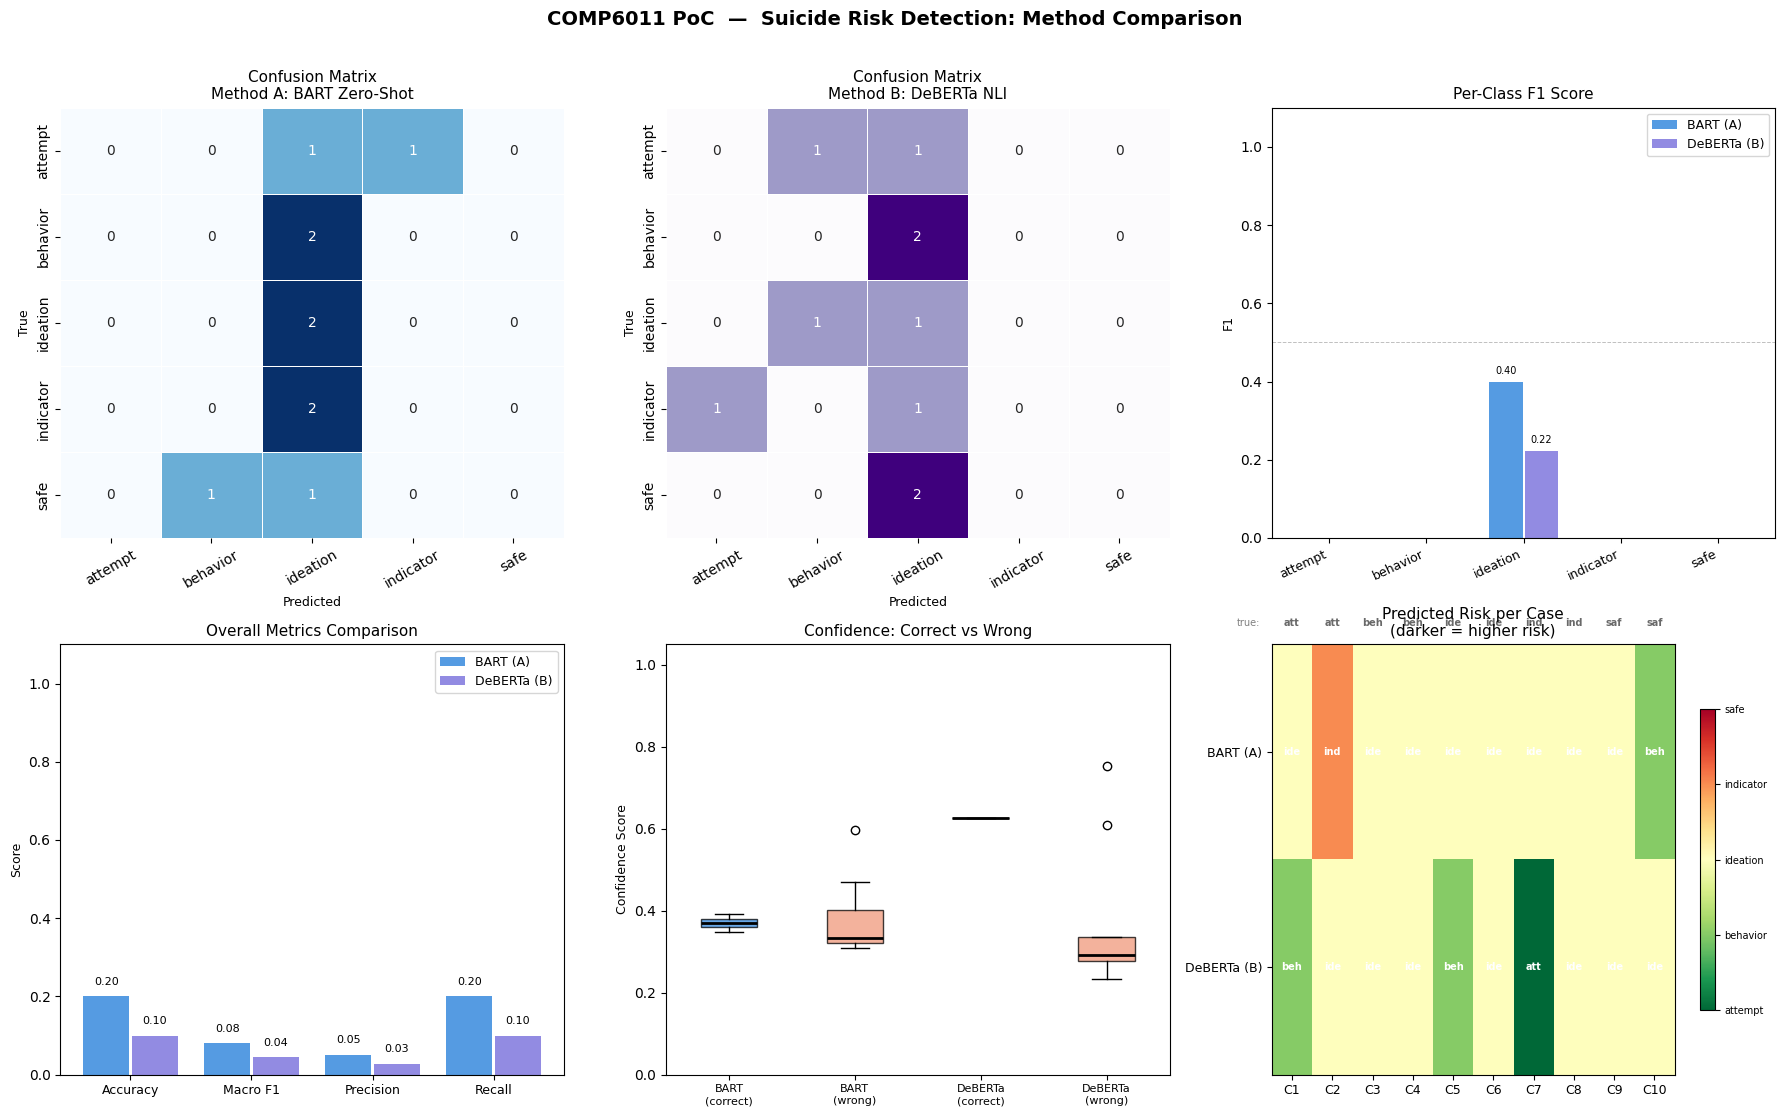

saved as poc_results.png


In [9]:
# plot all results — confusion matrices, f1 comparison, metrics, confidence, case heatmap

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('COMP6011 PoC  —  Suicide Risk Detection: Method Comparison',
             fontsize=14, fontweight='bold', y=1.01)

# confusion matrix A
ax = axes[0, 0]
cm_a = confusion_matrix(true, pred_a, labels=LABELS)
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=LABELS, yticklabels=LABELS, cbar=False, linewidths=0.5)
ax.set_title('Confusion Matrix\nMethod A: BART Zero-Shot', fontsize=11)
ax.set_xlabel('Predicted', fontsize=9)
ax.set_ylabel('True', fontsize=9)
ax.tick_params(axis='x', rotation=30)

# confusion matrix B
ax = axes[0, 1]
cm_b = confusion_matrix(true, pred_b, labels=LABELS)
sns.heatmap(cm_b, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=LABELS, yticklabels=LABELS, cbar=False, linewidths=0.5)
ax.set_title('Confusion Matrix\nMethod B: DeBERTa NLI', fontsize=11)
ax.set_xlabel('Predicted', fontsize=9)
ax.set_ylabel('True', fontsize=9)
ax.tick_params(axis='x', rotation=30)

# per-class f1
ax = axes[0, 2]
f1_a = f1_score(true, pred_a, labels=LABELS, average=None, zero_division=0)
f1_b = f1_score(true, pred_b, labels=LABELS, average=None, zero_division=0)
x = np.arange(len(LABELS))
b1 = ax.bar(x - 0.18, f1_a, 0.34, label='BART (A)',    color='#378ADD', alpha=0.85)
b2 = ax.bar(x + 0.18, f1_b, 0.34, label='DeBERTa (B)', color='#7F77DD', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(LABELS, rotation=25, ha='right', fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title('Per-Class F1 Score', fontsize=11)
ax.set_ylabel('F1', fontsize=9)
ax.legend(fontsize=9)
ax.axhline(0.5, color='grey', linestyle='--', linewidth=0.7, alpha=0.5)
for b in b1:
    h = b.get_height()
    if h > 0.01: ax.text(b.get_x()+b.get_width()/2, h+0.02, f'{h:.2f}', ha='center', fontsize=7)
for b in b2:
    h = b.get_height()
    if h > 0.01: ax.text(b.get_x()+b.get_width()/2, h+0.02, f'{h:.2f}', ha='center', fontsize=7)

# overall metrics bar
ax = axes[1, 0]
metric_names = ['accuracy', 'macro_f1', 'precision', 'recall']
metric_labels = ['Accuracy', 'Macro F1', 'Precision', 'Recall']
vals_a = [m_a[k] for k in metric_names]
vals_b = [m_b[k] for k in metric_names]
x2 = np.arange(len(metric_names))
ax.bar(x2 - 0.2, vals_a, 0.38, label='BART (A)',    color='#378ADD', alpha=0.85)
ax.bar(x2 + 0.2, vals_b, 0.38, label='DeBERTa (B)', color='#7F77DD', alpha=0.85)
ax.set_xticks(x2)
ax.set_xticklabels(metric_labels, fontsize=9)
ax.set_ylim(0, 1.1)
ax.set_title('Overall Metrics Comparison', fontsize=11)
ax.set_ylabel('Score', fontsize=9)
ax.legend(fontsize=9)
for i, (va, vb) in enumerate(zip(vals_a, vals_b)):
    ax.text(i-0.2, va+0.03, f'{va:.2f}', ha='center', fontsize=8)
    ax.text(i+0.2, vb+0.03, f'{vb:.2f}', ha='center', fontsize=8)

# confidence boxplot
ax = axes[1, 1]
groups = [
    combined.loc[combined['correct_a'],  'conf_a'].tolist(),
    combined.loc[~combined['correct_a'], 'conf_a'].tolist(),
    combined.loc[combined['correct_b'],  'conf_b'].tolist(),
    combined.loc[~combined['correct_b'], 'conf_b'].tolist()
]
group_labels = ['BART\n(correct)', 'BART\n(wrong)', 'DeBERTa\n(correct)', 'DeBERTa\n(wrong)']
group_colors = ['#378ADD', '#F0997B', '#7F77DD', '#F0997B']
bp = ax.boxplot([g if g else [0] for g in groups], patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, col in zip(bp['boxes'], group_colors):
    patch.set_facecolor(col)
    patch.set_alpha(0.75)
ax.set_xticks(range(1, 5))
ax.set_xticklabels(group_labels, fontsize=8)
ax.set_ylim(0, 1.05)
ax.set_title('Confidence: Correct vs Wrong', fontsize=11)
ax.set_ylabel('Confidence Score', fontsize=9)

# per-case prediction heatmap
ax = axes[1, 2]
grid = np.array([[LABEL2ID[p] for p in pred_a],
                 [LABEL2ID[p] for p in pred_b]], dtype=float)
im = ax.imshow(grid, cmap='RdYlGn_r', aspect='auto', vmin=0, vmax=4)
ax.set_yticks([0, 1])
ax.set_yticklabels(['BART (A)', 'DeBERTa (B)'], fontsize=9)
ax.set_xticks(range(len(combined)))
ax.set_xticklabels([f'C{int(i)}' for i in combined['case_id']], fontsize=9)
ax.set_title('Predicted Risk per Case\n(darker = higher risk)', fontsize=11)
for j, p in enumerate(pred_a):
    ax.text(j, 0, p[:3], ha='center', va='center', fontsize=7, color='white', fontweight='bold')
for j, p in enumerate(pred_b):
    ax.text(j, 1, p[:3], ha='center', va='center', fontsize=7, color='white', fontweight='bold')
for j, t in enumerate(true):
    ax.text(j, -0.6, t[:3], ha='center', va='center', fontsize=7, color='dimgray', fontweight='bold')
ax.text(-0.8, -0.6, 'true:', ha='right', va='center', fontsize=7, color='gray')
cbar = plt.colorbar(im, ax=ax, shrink=0.7)
cbar.set_ticks([0, 1, 2, 3, 4])
cbar.set_ticklabels(LABELS, fontsize=7)

plt.tight_layout()
plt.savefig('poc_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved as poc_results.png')

In [10]:
# case by case breakdown

print('case-by-case results')
print('=' * 60)

for _, row in combined.iterrows():
    a_ok = 'correct' if row['correct_a'] else 'wrong'
    b_ok = 'correct' if row['correct_b'] else 'wrong'
    a_err = abs(LABEL2ID[row['pred_a']] - LABEL2ID[row['true_label']])
    b_err = abs(LABEL2ID[row['pred_b']] - LABEL2ID[row['true_label']])
    print(f"\ncase {int(row['case_id'])}")
    print(f"  true label   : {row['true_label']}")
    print(f"  BART pred    : {row['pred_a']}  (conf={row['conf_a']:.2f})  {a_ok}  ordinal_err={a_err}")
    print(f"  DeBERTa pred : {row['pred_b']}  (conf={row['conf_b']:.2f})  {b_ok}  ordinal_err={b_err}")

print()
print('=' * 60)
print('agreement analysis')
print('=' * 60)
both_right  = (combined['correct_a'] & combined['correct_b']).sum()
both_wrong  = (~combined['correct_a'] & ~combined['correct_b']).sum()
only_a      = (combined['correct_a'] & ~combined['correct_b']).sum()
only_b      = (~combined['correct_a'] & combined['correct_b']).sum()
agreement   = (combined['pred_a'] == combined['pred_b']).sum()
inter_kappa = cohen_kappa_score(pred_a, pred_b, labels=LABELS, weights='quadratic')
print(f'  both correct       : {both_right}/10')
print(f'  both wrong         : {both_wrong}/10')
print(f'  only BART correct  : {only_a}/10')
print(f'  only DeBERTa corr  : {only_b}/10')
print(f'  same prediction    : {agreement}/10 cases')
print(f'  inter-model kappa  : {inter_kappa:.3f}')

print()
print('=' * 60)
print('clinical safety  —  false negatives on high-risk cases')
print('=' * 60)
high_risk = combined[combined['true_label'].isin(['attempt', 'behavior'])]
fn_a = (~high_risk['correct_a']).sum()
fn_b = (~high_risk['correct_b']).sum()
print(f'  high-risk cases total  : {len(high_risk)}')
print(f'  BART missed (FN)       : {fn_a}')
print(f'  DeBERTa missed (FN)    : {fn_b}')
print()
print('  false negatives on high-risk cases are the most dangerous')
print('  error type in a clinical screening context because they')
print('  represent missed referrals to mental health professionals.')

case-by-case results

case 1
  true label   : attempt
  BART pred    : ideation  (conf=0.60)  wrong  ordinal_err=2
  DeBERTa pred : behavior  (conf=0.29)  wrong  ordinal_err=1

case 2
  true label   : attempt
  BART pred    : indicator  (conf=0.38)  wrong  ordinal_err=3
  DeBERTa pred : ideation  (conf=0.23)  wrong  ordinal_err=2

case 3
  true label   : behavior
  BART pred    : ideation  (conf=0.33)  wrong  ordinal_err=1
  DeBERTa pred : ideation  (conf=0.34)  wrong  ordinal_err=1

case 4
  true label   : behavior
  BART pred    : ideation  (conf=0.34)  wrong  ordinal_err=1
  DeBERTa pred : ideation  (conf=0.28)  wrong  ordinal_err=1

case 5
  true label   : ideation
  BART pred    : ideation  (conf=0.35)  correct  ordinal_err=0
  DeBERTa pred : behavior  (conf=0.24)  wrong  ordinal_err=1

case 6
  true label   : ideation
  BART pred    : ideation  (conf=0.39)  correct  ordinal_err=0
  DeBERTa pred : ideation  (conf=0.63)  correct  ordinal_err=0

case 7
  true label   : indicator
  B

In [11]:
# export results to csv and print final summary

export = combined[['case_id', 'true_label',
                   'pred_a', 'conf_a', 'correct_a',
                   'pred_b', 'conf_b', 'correct_b']].copy()

export['ordinal_err_a'] = export.apply(
    lambda r: abs(LABEL2ID[r['pred_a']] - LABEL2ID[r['true_label']]), axis=1)
export['ordinal_err_b'] = export.apply(
    lambda r: abs(LABEL2ID[r['pred_b']] - LABEL2ID[r['true_label']]), axis=1)

export.to_csv('poc_results_table.csv', index=False)
print('results saved to poc_results_table.csv')
print()
display(export)

print()
print('=' * 60)
print('final summary')
print('=' * 60)
print(f"method A  BART large zero-shot")
print(f"  accuracy={m_a['accuracy']:.1%}  macro_f1={m_a['macro_f1']:.3f}  kappa={m_a['cohen_kappa']:.3f}  mae={m_a['ordinal_mae']:.3f}")
print(f"method B  DeBERTa NLI zero-shot")
print(f"  accuracy={m_b['accuracy']:.1%}  macro_f1={m_b['macro_f1']:.3f}  kappa={m_b['cohen_kappa']:.3f}  mae={m_b['ordinal_mae']:.3f}")
print()
winner = 'method A (BART)' if m_a['macro_f1'] >= m_b['macro_f1'] else 'method B (DeBERTa)'
print(f'higher macro f1: {winner}')
print()
print('note: n=10 is not sufficient for statistically valid conclusions.')
print('all results are illustrative poc outputs only.')
print()
print('dataset citation:')
print('Chen, X., Li, Q., Jiang, Y., Liu, M., Yang, L., Jing, X., Wei, Z., & Cao, L. (2026).')
print('Human-AI-Dialogue-Suicide-Risk-Dataset [Data set]. Zenodo.')
print('https://doi.org/10.5281/zenodo.18684594')

results saved to poc_results_table.csv



,case_id,true_label,pred_a,conf_a,correct_a,pred_b,conf_b,correct_b,ordinal_err_a,ordinal_err_b
0,1,attempt,ideation,0.597,False,behavior,0.292,False,2,1
1,2,attempt,indicator,0.378,False,ideation,0.233,False,3,2
2,3,behavior,ideation,0.327,False,ideation,0.336,False,1,1
3,4,behavior,ideation,0.339,False,ideation,0.278,False,1,1
4,5,ideation,ideation,0.349,True,behavior,0.240,False,0,1
5,6,ideation,ideation,0.391,True,ideation,0.626,True,0,0
6,7,indicator,ideation,0.469,False,attempt,0.301,False,1,3
7,8,indicator,ideation,0.324,False,ideation,0.277,False,1,1
8,9,safe,ideation,0.308,False,ideation,0.754,False,2,2
9,10,safe,behavior,0.317,False,ideation,0.609,False,3,2



final summary
method A  BART large zero-shot
  accuracy=20.0%  macro_f1=0.080  kappa=-0.364  mae=1.400
method B  DeBERTa NLI zero-shot
  accuracy=10.0%  macro_f1=0.044  kappa=0.000  mae=1.400

higher macro f1: method A (BART)

note: n=10 is not sufficient for statistically valid conclusions.
all results are illustrative poc outputs only.

dataset citation:
Chen, X., Li, Q., Jiang, Y., Liu, M., Yang, L., Jing, X., Wei, Z., & Cao, L. (2026).
Human-AI-Dialogue-Suicide-Risk-Dataset [Data set]. Zenodo.
https://doi.org/10.5281/zenodo.18684594


In [12]:
# load the two external datasets directly from HuggingFace
# no manual download needed
from datasets import load_dataset
import pandas as pd
import numpy as np

print("loading datasets...")

# Dataset 1: Suicide and Depression Detection (Komati, 2022)
# binary labels: suicide / non-suicide
# source: https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch
ds1 = load_dataset("vibhorag101/suicide_prediction_dataset_phr", split="train")
df1 = ds1.to_pandas()
print(f"Dataset 1 loaded: {len(df1)} rows")
print(df1.columns.tolist())
print(df1.iloc[:, -1].value_counts())

loading datasets...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-2ab36d8ba3acdb(…):   0%|          | 0.00/42.9M [00:00<?, ?B/s]

data/test-00000-of-00001-a1bf8c09fedae1d(…):   0%|          | 0.00/10.6M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/185574 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/46394 [00:00<?, ? examples/s]

Dataset 1 loaded: 185574 rows
['text', 'label']
label
suicide        92889
non-suicide    92685
Name: count, dtype: int64


In [14]:
# Dataset 2: Mental Health Text Classification (ourafla, 2025)
# 4 classes: Suicidal, Depression, Anxiety, Normal
# publicly available, no login needed
# source: https://huggingface.co/datasets/ourafla/Mental-Health_Text-Classification_Dataset

ds2 = load_dataset("ourafla/Mental-Health_Text-Classification_Dataset",
                   data_files={"train": "mental_heath_unbanlanced.csv"},
                   split="train")
df2 = ds2.to_pandas()
print(f"Dataset 2 loaded: {len(df2)} rows")
print(df2.columns.tolist())
print(df2.iloc[:, -1].value_counts())

README.md: 0.00B [00:00, ?B/s]

mental_heath_unbanlanced.csv:   0%|          | 0.00/20.8M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Dataset 2 loaded: 49612 rows
['Unique_ID', 'text', 'status']
status
Normal        18391
Depression    14506
Suicidal      11212
Anxiety        5503
Name: count, dtype: int64


In [15]:
# prepare Dataset 1
# mapping suicide -> ideation and non-suicide -> safe
# this is a simplification since the dataset has no severity metadata
# conservative mapping: suicide posts are not assumed to be attempt-level

text_col1  = 'text'
label_col1 = df1.columns[-1]

df1[label_col1] = df1[label_col1].astype(str).str.lower().str.strip()
df1 = df1[df1[label_col1].isin(['suicide', 'non-suicide'])].copy()

BINARY_MAP = {'suicide': 'ideation', 'non-suicide': 'safe'}
df1['mapped_label'] = df1[label_col1].map(BINARY_MAP)

# take 75 samples per class to keep runtime reasonable
n = 75
df1_sample = pd.concat([
    df1[df1['mapped_label'] == 'ideation'].sample(n, random_state=42),
    df1[df1['mapped_label'] == 'safe'].sample(n, random_state=42)
]).reset_index(drop=True)

print(f"Dataset 1 sample: {len(df1_sample)} posts")
print(df1_sample['mapped_label'].value_counts())

Dataset 1 sample: 150 posts
mapped_label
ideation    75
safe        75
Name: count, dtype: int64


In [16]:
# prepare Dataset 2
# mapping to our 5-class scheme:
# Suicidal   -> ideation
# Depression -> indicator
# Anxiety    -> indicator
# Normal     -> safe

text_col2  = df2.columns[0]
label_col2 = df2.columns[-1]

df2[label_col2] = df2[label_col2].astype(str).str.strip()

MULTI_MAP = {
    'Suicidal'  : 'ideation',
    'Depression': 'indicator',
    'Anxiety'   : 'indicator',
    'Normal'    : 'safe',
}

df2 = df2[df2[label_col2].isin(MULTI_MAP.keys())].copy()
df2['mapped_label'] = df2[label_col2].map(MULTI_MAP)

# 50 samples per original class
frames = []
for lbl in MULTI_MAP.keys():
    subset = df2[df2[label_col2] == lbl]
    frames.append(subset.sample(min(50, len(subset)), random_state=42))
df2_sample = pd.concat(frames).reset_index(drop=True)

print(f"Dataset 2 sample: {len(df2_sample)} posts")
print(df2_sample['mapped_label'].value_counts())

Dataset 2 sample: 200 posts
mapped_label
indicator    100
ideation      50
safe          50
Name: count, dtype: int64


In [17]:
def run_benchmark(df, text_col, label_col, clf, candidates, hyp_map, model_name, dataset_name):
    results = []
    print(f"\n{model_name} on {dataset_name}")
    for _, row in df.iterrows():
        out  = clf(truncate(str(row[text_col])), candidate_labels=candidates, multi_label=False)
        pred = hyp_map[out['labels'][0]]
        conf = round(out['scores'][0], 3)
        true = row[label_col]
        results.append({'true': true, 'pred': pred, 'conf': conf, 'correct': pred == true})
    df_r = pd.DataFrame(results)
    print(f"  accuracy: {df_r['correct'].mean():.1%}  ({df_r['correct'].sum()}/{len(df_r)})")
    return df_r

# dataset 1
r_d1_a = run_benchmark(df1_sample, text_col1, 'mapped_label',
                        clf_a, candidates_a, hyp_to_label_a, 'BART (A)',    'Dataset 1')
r_d1_b = run_benchmark(df1_sample, text_col1, 'mapped_label',
                        clf_b, candidates_b, hyp_to_label_b, 'DeBERTa (B)', 'Dataset 1')

# dataset 2
r_d2_a = run_benchmark(df2_sample, text_col2, 'mapped_label',
                        clf_a, candidates_a, hyp_to_label_a, 'BART (A)',    'Dataset 2')
r_d2_b = run_benchmark(df2_sample, text_col2, 'mapped_label',
                        clf_b, candidates_b, hyp_to_label_b, 'DeBERTa (B)', 'Dataset 2')

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



BART (A) on Dataset 1
  accuracy: 12.0%  (18/150)

DeBERTa (B) on Dataset 1
  accuracy: 43.3%  (65/150)

BART (A) on Dataset 2
  accuracy: 25.0%  (50/200)

DeBERTa (B) on Dataset 2
  accuracy: 5.5%  (11/200)


In [18]:
# compute metrics for all four runs

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

def metrics(df_r, name):
    t = df_r['true'].tolist()
    p = df_r['pred'].tolist()
    lbls = sorted(set(t))
    return {
        'Run'      : name,
        'Accuracy' : round(accuracy_score(t, p), 3),
        'Macro F1' : round(f1_score(t, p, labels=lbls, average='macro',    zero_division=0), 3),
        'Precision': round(precision_score(t, p, labels=lbls, average='macro', zero_division=0), 3),
        'Recall'   : round(recall_score(t, p, labels=lbls, average='macro',    zero_division=0), 3),
    }

# results
our_rows = [
    metrics(r_d1_a, 'BART (A)    — Dataset 1 (Komati 2022)'),
    metrics(r_d1_b, 'DeBERTa (B) — Dataset 1 (Komati 2022)'),
    metrics(r_d2_a, 'BART (A)    — Dataset 2 (SWMH / Ji 2021)'),
    metrics(r_d2_b, 'DeBERTa (B) — Dataset 2 (SWMH / Ji 2021)'),
]

# published results from literature added for comparison
# source: arXiv:2505.13480 — zero-shot LLMs on Reddit r/SuicideWatch (C-SSRS)
published_rows = [
    {'Run': 'Claude 3.5   [arXiv:2505.13480, zero-shot]', 'Accuracy': 0.733, 'Macro F1': 0.751, 'Precision': 0.788, 'Recall': 0.733},
    {'Run': 'GPT-4        [arXiv:2505.13480, zero-shot]', 'Accuracy': 0.728, 'Macro F1': 0.738, 'Precision': None,  'Recall': None},
    {'Run': 'Mistral 7B   [arXiv:2505.13480, zero-shot]', 'Accuracy': None,  'Macro F1': 0.721, 'Precision': None,  'Recall': None},
    {'Run': 'RoBERTa      [J.Med.Sys 2024,  fine-tuned]', 'Accuracy': 0.974, 'Macro F1': None,  'Precision': None,  'Recall': 0.912},
]

df_bench_table = pd.DataFrame(our_rows + published_rows).set_index('Run')
print("Benchmarking Comparison Table")
print("(our zero-shot results vs published numbers from literature)\n")
display(df_bench_table)

Benchmarking Comparison Table
(our zero-shot results vs published numbers from literature)



,Accuracy,Macro F1,Precision,Recall
Run,,,,
BART (A) — Dataset 1 (Komati 2022),0.120,0.142,0.460,0.120
DeBERTa (B) — Dataset 1 (Komati 2022),0.433,0.342,0.587,0.433
BART (A) — Dataset 2 (SWMH / Ji 2021),0.250,0.133,0.083,0.333
DeBERTa (B) — Dataset 2 (SWMH / Ji 2021),0.055,0.064,0.056,0.073
"Claude 3.5 [arXiv:2505.13480, zero-shot]",0.733,0.751,0.788,0.733
"GPT-4 [arXiv:2505.13480, zero-shot]",0.728,0.738,NaN,NaN
"Mistral 7B [arXiv:2505.13480, zero-shot]",NaN,0.721,NaN,NaN
"RoBERTa [J.Med.Sys 2024, fine-tuned]",0.974,NaN,NaN,0.912


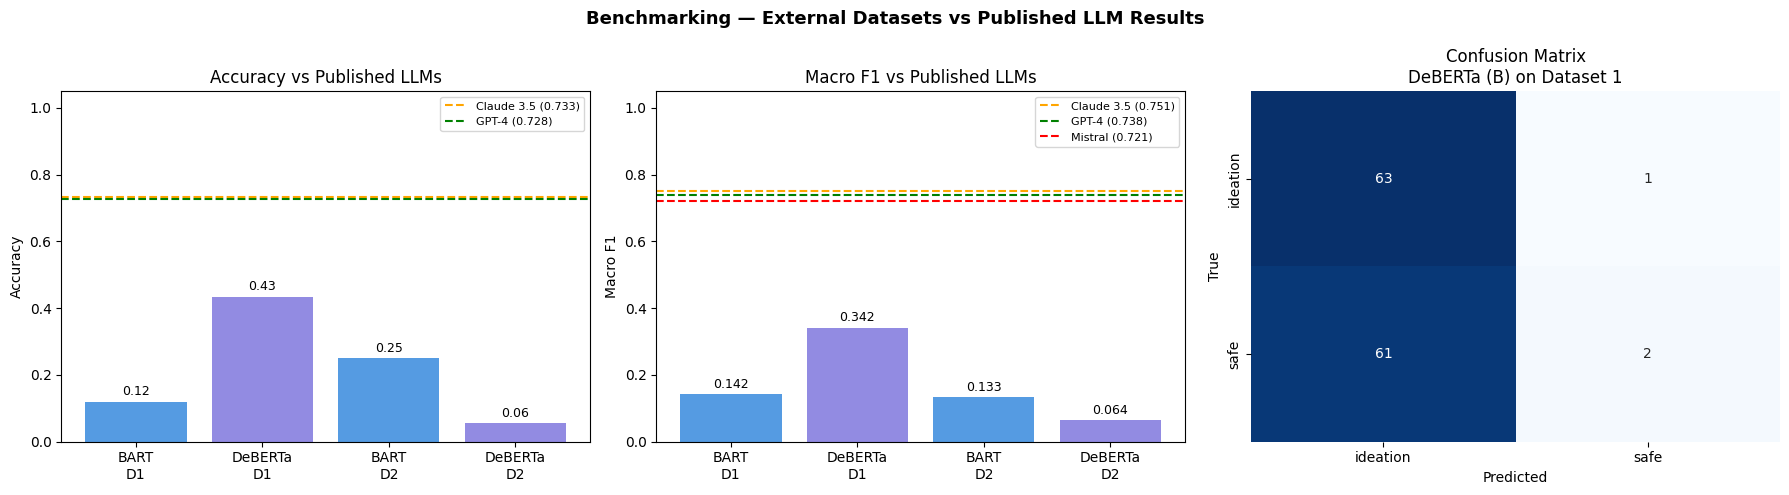

saved as benchmarking_results.png


In [19]:
# plot benchmarking results

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Benchmarking — External Datasets vs Published LLM Results', fontsize=13, fontweight='bold')

# chart 1: accuracy
ax = axes[0]
labels_plot = ['BART\nD1', 'DeBERTa\nD1', 'BART\nD2', 'DeBERTa\nD2']
accs = [r['Accuracy'] for r in our_rows]
bars = ax.bar(labels_plot, accs, color=['#378ADD','#7F77DD','#378ADD','#7F77DD'], alpha=0.85)
ax.axhline(0.733, color='orange', linestyle='--', linewidth=1.5, label='Claude 3.5 (0.733)')
ax.axhline(0.728, color='green',  linestyle='--', linewidth=1.5, label='GPT-4 (0.728)')
ax.set_ylim(0, 1.05)
ax.set_title('Accuracy vs Published LLMs')
ax.set_ylabel('Accuracy')
ax.legend(fontsize=8)
for b, v in zip(bars, accs):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

# chart 2: macro f1
ax = axes[1]
f1s = [r['Macro F1'] for r in our_rows]
bars2 = ax.bar(labels_plot, f1s, color=['#378ADD','#7F77DD','#378ADD','#7F77DD'], alpha=0.85)
ax.axhline(0.751, color='orange', linestyle='--', linewidth=1.5, label='Claude 3.5 (0.751)')
ax.axhline(0.738, color='green',  linestyle='--', linewidth=1.5, label='GPT-4 (0.738)')
ax.axhline(0.721, color='red',    linestyle='--', linewidth=1.5, label='Mistral (0.721)')
ax.set_ylim(0, 1.05)
ax.set_title('Macro F1 vs Published LLMs')
ax.set_ylabel('Macro F1')
ax.legend(fontsize=8)
for b, v in zip(bars2, f1s):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f'{v:.3f}', ha='center', fontsize=9)

# chart 3: confusion matrix for best performer on dataset 1
ax = axes[2]
best_r  = r_d1_a if accs[0] >= accs[1] else r_d1_b
best_nm = 'BART (A)' if accs[0] >= accs[1] else 'DeBERTa (B)'
cm_lbls = sorted(best_r['true'].unique())
cm = confusion_matrix(best_r['true'], best_r['pred'], labels=cm_lbls)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=cm_lbls, yticklabels=cm_lbls, cbar=False)
ax.set_title(f'Confusion Matrix\n{best_nm} on Dataset 1')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')

plt.tight_layout()
plt.savefig('benchmarking_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("saved as benchmarking_results.png")

In [21]:
# quick notes on limitations
print("Limitations of this benchmarking evaluation:")
print()
print("1. Label mapping: both external datasets use binary or subreddit-level labels.")
print("   These don't map perfectly to our 5-class scheme. 'suicide' posts are")
print("   conservatively mapped to ideation rather than attempt because no")
print("   plan or intent metadata is available in either dataset.")
print()
print("2. Domain gap: external datasets are Reddit posts (short, informal text).")
print("   Our PoC uses structured multi-turn dialogue transcripts, which are")
print("   longer and more conversational. Performance differences are expected.")
print()
print("3. Sample size: 150 and ~200 posts respectively. Enough for illustration,")
print("   not enough for statistically valid conclusions.")
print()
print("4. All results are zero-shot. Published LLM numbers (Claude, GPT-4)")
print("   also reflect zero-shot settings. RoBERTa result is fine-tuned,")
print("   included only to show the upper bound of supervised approaches.")
print()
print("Dataset citations:")
print("  Komati, N. (2022). Suicide and Depression Detection. Kaggle.")
print("  https://www.kaggle.com/datasets/nikhileswarkomati/suicide-watch")
print()
print("  Mukherjee, P. (2025). Mental Health Text Classification Dataset.")
print("  https://huggingface.co/datasets/ourafla/Mental-Health_Text-Classification_Dataset")

Limitations of this benchmarking evaluation:

1. Label mapping: both external datasets use binary or subreddit-level labels.
   These don't map perfectly to our 5-class scheme. 'suicide' posts are
   conservatively mapped to ideation rather than attempt because no
   plan or intent metadata is available in either dataset.

2. Domain gap: external datasets are Reddit posts (short, informal text).
   Our PoC uses structured multi-turn dialogue transcripts, which are
   longer and more conversational. Performance differences are expected.

3. Sample size: 150 and ~200 posts respectively. Enough for illustration,
   not enough for statistically valid conclusions.

4. All results are zero-shot. Published LLM numbers (Claude, GPT-4)
   also reflect zero-shot settings. RoBERTa result is fine-tuned,
   included only to show the upper bound of supervised approaches.

Dataset citations:
  Komati, N. (2022). Suicide and Depression Detection. Kaggle.
  https://www.kaggle.com/datasets/nikhileswarko